## Question 1

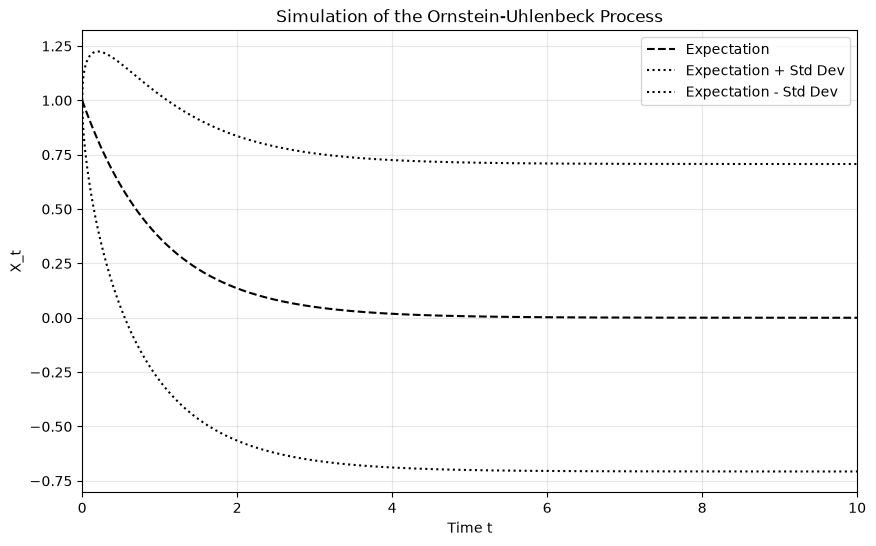

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x, lam, sigma = 1.0, 1.0, 1.0

T = 10.0
dt = 0.01
N = int(T / dt)

t = np.linspace(0, T, N)

mean_X_t = np.exp(-lam * t)
var_X_t = (sigma**2/(2*lam)) - ((sigma**2/(2*lam)) * np.exp(-2 * lam * t))
std_X_t = np.sqrt(var_X_t)

upper = mean_X_t + std_X_t
lower = mean_X_t - std_X_t

plt.figure(figsize=(10, 6))

plt.plot(t, mean_X_t, label='Expectation', color='black', linestyle='--')
plt.plot(t, upper, label='Expectation + Std Dev', color='black', linestyle=':')
plt.plot(t, lower, label='Expectation - Std Dev', color='black', linestyle=':')

plt.xlabel('Time t')
plt.ylabel('X_t')
plt.title('Simulation of the Ornstein-Uhlenbeck Process')
plt.xlim([0, T])
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Question 3

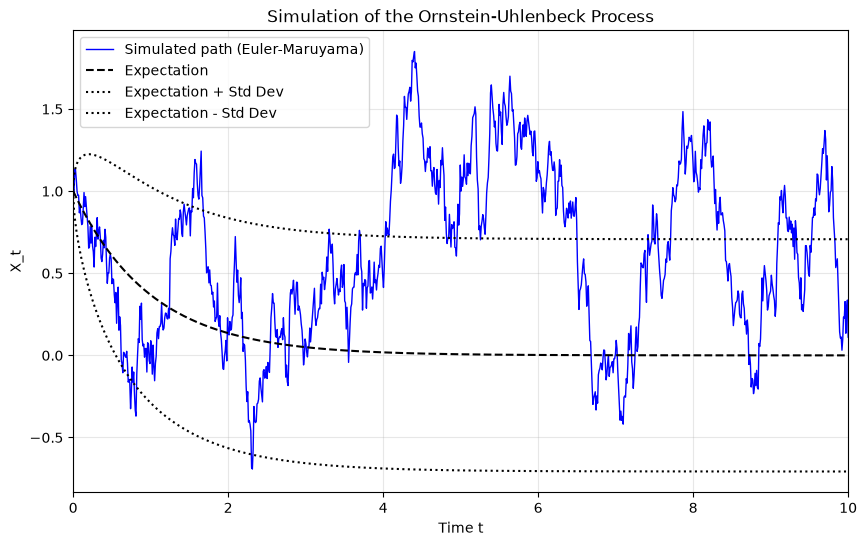

In [3]:
import numpy as np
import matplotlib.pyplot as plt

X = np.zeros(N)
X[0] = x

np.random.seed(1312)
Z = np.random.normal(0, 1, N)

for i in range(1, N):
    X[i] = X[i-1] - lam * X[i-1] * dt + sigma * np.sqrt(dt) * Z[i]
    
plt.figure(figsize=(10, 6))

plt.plot(t, X, label='Simulated path (Euler-Maruyama)', color='blue', linewidth=1)
plt.plot(t, mean_X_t, label='Expectation', color='black', linestyle='--')
plt.plot(t, upper, label='Expectation + Std Dev', color='black', linestyle=':')
plt.plot(t, lower, label='Expectation - Std Dev', color='black', linestyle=':')

plt.xlabel('Time t')
plt.ylabel('X_t')
plt.title('Simulation of the Ornstein-Uhlenbeck Process')
plt.xlim([0, T])
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Question 5

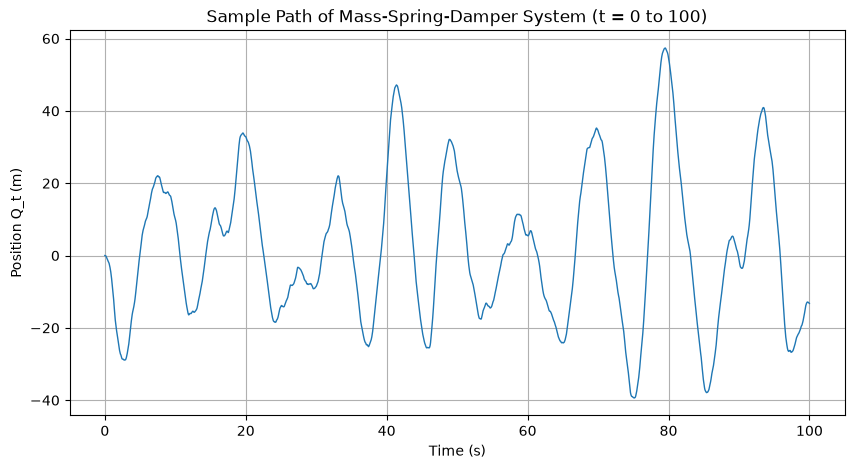

In [4]:
import numpy as np
import matplotlib.pyplot as plt

m, k, c = 1.0, 0.5, 0.2
sigma = 10.0 # sqrt of 100
dt = 0.01
T = 1000
N = int(T / dt)

A = np.array([[0, 1], 
              [-k/m, -c/m]])
G = np.array([0, sigma/m])

X = np.zeros((N, 2))
Z = np.random.normal(0, 1, N)

for i in range(1, N):
    X[i] = X[i-1] + (A @ X[i-1]) * dt + G * np.sqrt(dt) * Z[i]
    
time = np.arange(0, T, dt)
limit = int(100 / dt)  # number of steps to reach t=100

plt.figure(figsize=(10, 5))
plt.plot(time[:limit], X[:limit, 0], linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Position Q_t (m)')
plt.title('Sample Path of Mass-Spring-Damper System (t = 0 to 100)')
plt.grid(True)
plt.show()

## Question 6

In [5]:
import numpy as np
import scipy as sc

A = np.array([[0, 1], 
              [-k/m, -c/m]])
G = np.array([[0],
              [sigma/m]])
q = - (G @ G.T)

est_cov = np.cov(X[int(N/2):].T)
theo_cov = sc.linalg.solve_continuous_lyapunov(A, q)

print("Theoretical Steady-State Covariance:")
print(theo_cov)

print("\nEmpirical Estimated Covariance:")
print(est_cov)

print("\nAbsolute Difference (Error):")
print(np.abs(theo_cov - est_cov))

Theoretical Steady-State Covariance:
[[ 5.00000000e+02 -3.72592051e-15]
 [-4.00280913e-15  2.50000000e+02]]

Empirical Estimated Covariance:
[[458.88428248  -1.36488684]
 [ -1.36488684 228.48823084]]

Absolute Difference (Error):
[[41.11571752  1.36488684]
 [ 1.36488684 21.51176916]]


## Question 8

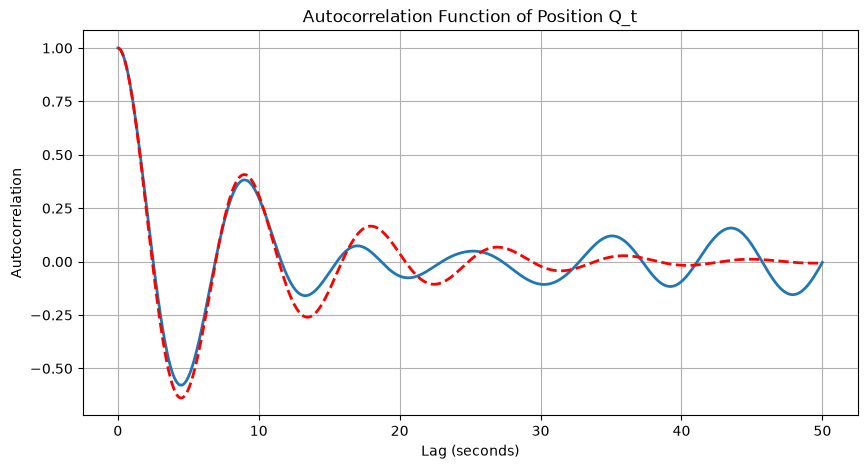

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from statsmodels.tsa.stattools import acf

steady_state_Q = X[int(N/2):, 0]

lags = 5000
empirical_acf = acf(steady_state_Q, nlags=lags)

tau = np.linspace(0, 50, lags + 1)

theo_acf = []
for t in tau:
    C_tau = sc.linalg.expm(A * t) @ theo_cov
    acf_val = C_tau[0, 0] / theo_cov[0, 0]
    theo_acf.append(acf_val)
    
plt.figure(figsize=(10, 5))
plt.plot(tau, empirical_acf, label='Empirical ACF', linewidth=2)
plt.plot(tau, theo_acf, label='Theoretical ACF', linestyle='--', color='red', linewidth=2)
plt.xlabel('Lag (seconds)')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function of Position Q_t')
plt.grid(True)

## Question 9

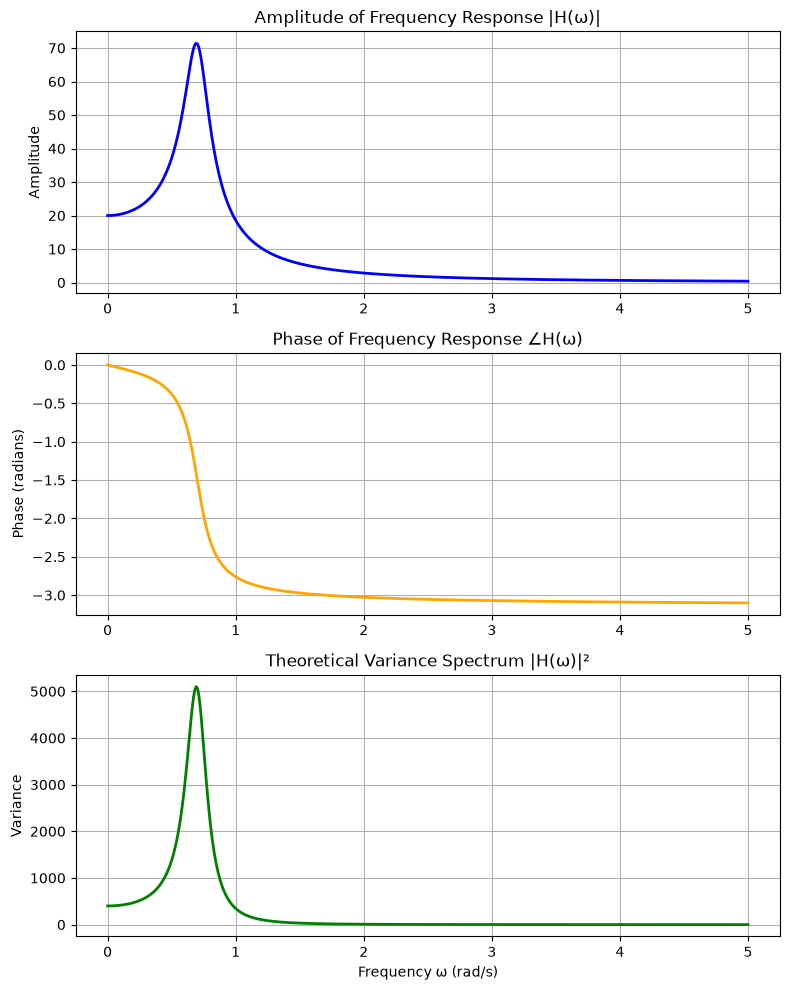

In [11]:
import numpy as np
import matplotlib.pyplot as plt

m = 1.0
k = 0.5
c = 0.2
sigma = 10.0

omega = np.linspace(0, 5, 500)


H = sigma / ((k - m * omega**2) + 1j * omega * c)

amplitude = np.abs(H)
phase = np.angle(H)
variance_spectrum = np.abs(H)**2

fig, axs = plt.subplots(3, 1, figsize=(8, 10))

axs[0].plot(omega, amplitude, color='blue', linewidth=2)
axs[0].set_title('Amplitude of Frequency Response |H(ω)|')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

axs[1].plot(omega, phase, color='orange', linewidth=2)
axs[1].set_title('Phase of Frequency Response ∠H(ω)')
axs[1].set_ylabel('Phase (radians)')
axs[1].grid(True)

axs[2].plot(omega, variance_spectrum, color='green', linewidth=2)
axs[2].set_title('Theoretical Variance Spectrum |H(ω)|²')
axs[2].set_xlabel('Frequency ω (rad/s)')
axs[2].set_ylabel('Variance')
axs[2].grid(True)

plt.tight_layout()
plt.show()